In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/tyre_project')


### 1- Load the Cleaned Dataset
We load the pre-processed F1 2024 lap data (with feature engineering) from the `clean` folder.  
This dataset already includes the engineered features like `stint_mean`, `lap_time_rel`, and `lap_time_norm`.



In [ ]:
import pandas as pd

df = pd.read_csv('clean/clean_laps_2024_fe.csv')
df.head()


,driver,team,lap_number,LapTime,compound,is_pit,stint,lap_start_time,lap_time_s,year,event,round,stint_index,lap_index_in_stint,stint_length,stint_mean,lap_time_rel,lap_time_norm
0,ALB,Williams,1,0 days 00:01:43.888000,SOFT,False,1.0,0 days 00:59:59.911000,103.888,2024,Bahrain Grand Prix,1,1,0,56,98.511214,5.376786,1.054580
1,ALO,Aston Martin,1,0 days 00:01:41.679000,SOFT,False,1.0,0 days 00:59:59.911000,101.679,2024,Bahrain Grand Prix,1,1,0,57,97.888228,3.790772,1.038726
2,BOT,Kick Sauber,1,0 days 00:01:48.536000,SOFT,False,1.0,0 days 00:59:59.911000,108.536,2024,Bahrain Grand Prix,1,1,0,55,98.503745,10.032255,1.101846
3,GAS,Alpine,1,0 days 00:01:47.240000,SOFT,False,1.0,0 days 00:59:59.911000,107.240,2024,Bahrain Grand Prix,1,1,0,56,98.877839,8.362161,1.084571
4,HAM,Mercedes,1,0 days 00:01:43.122000,SOFT,False,1.0,0 days 00:59:59.911000,103.122,2024,Bahrain Grand Prix,1,1,0,57,97.457298,5.664702,1.058125



###2- Prepare Inputs for Modelling
We select the features and the target variable for prediction.  
- **Features:** `lap_index_in_stint`, `compound`, `driver`, and `event`.  
- **Target:** `lap_time_s` (lap time in seconds).  
Categorical variables are one-hot encoded, while the numeric variable is passed as is.


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error

features = ['lap_index_in_stint', 'compound', 'driver', 'event']
target = 'lap_time_s'

X = df[features]
y = df[target]

categorical = ['compound', 'driver', 'event']
numeric = ['lap_index_in_stint']

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', 'passthrough', numeric)
])


###3- Baseline 1 — Linear Regression
We train a Linear Regression model to predict lap times based on the selected features.  
The dataset is split 80/20 into training and testing subsets.  
We evaluate performance using the Mean Absolute Error (MAE) overall and by race event.


In [ ]:
linreg = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
linreg.fit(X_train, y_train)

preds = linreg.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"Linear Regression MAE: {mae} s")


Linear Regression MAE: 3.709818838490978 s


In [ ]:
df_test = X_test.copy()
df_test['y_true'] = y_test
df_test['y_pred'] = preds
print(df_test.groupby('event').apply(lambda g: mean_absolute_error(g['y_true'], g['y_pred'])).sort_values())


event
Monaco Grand Prix             1.495023
Dutch Grand Prix              1.501951
Spanish Grand Prix            1.639229
Belgian Grand Prix            1.732759
Bahrain Grand Prix            1.738857
Singapore Grand Prix          1.775000
Hungarian Grand Prix          1.829483
Emilia Romagna Grand Prix     1.862320
Azerbaijan Grand Prix         1.893328
Italian Grand Prix            2.177903
Austrian Grand Prix           2.242666
Las Vegas Grand Prix          2.502382
Abu Dhabi Grand Prix          2.861577
Saudi Arabian Grand Prix      2.948593
United States Grand Prix      3.012679
Australian Grand Prix         3.210533
Japanese Grand Prix           3.253161
Miami Grand Prix              4.553043
British Grand Prix            4.769807
São Paulo Grand Prix          6.835769
Mexico City Grand Prix        6.987630
Canadian Grand Prix           8.017534
Chinese Grand Prix            9.824467
Qatar Grand Prix             12.682728
dtype: float64


/tmp/ipython-input-76266418.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df_test.groupby('event').apply(lambda g: mean_absolute_error(g['y_true'], g['y_pred'])).sort_values())


###4- Baseline 2 — Ridge Regression
We apply Ridge Regression, which adds L2 regularization to the linear model to prevent overfitting.  
The same preprocessing pipeline is reused.  
We again compute MAE overall and per race event.


In [ ]:
ridge = Pipeline([
    ('preprocess', preprocess),
    ('model', Ridge(alpha=1.0))
])

ridge.fit(X_train, y_train)
preds_ridge = ridge.predict(X_test)

print("Ridge Regression MAE:", mean_absolute_error(y_test, preds_ridge))


Ridge Regression MAE: 3.7103974269093167


In [ ]:
df_test_ridge = X_test.copy()
df_test_ridge['y_true'] = y_test
df_test_ridge['y_pred'] = preds_ridge

print(
    df_test_ridge.groupby('event')
    .apply(lambda g: mean_absolute_error(g['y_true'], g['y_pred']))
    .sort_values()
)


event
Monaco Grand Prix             1.499653
Dutch Grand Prix              1.506181
Spanish Grand Prix            1.644477
Belgian Grand Prix            1.717189
Bahrain Grand Prix            1.733666
Singapore Grand Prix          1.776059
Hungarian Grand Prix          1.830491
Emilia Romagna Grand Prix     1.869121
Azerbaijan Grand Prix         1.879224
Italian Grand Prix            2.182684
Austrian Grand Prix           2.250451
Las Vegas Grand Prix          2.500061
Abu Dhabi Grand Prix          2.860378
Saudi Arabian Grand Prix      2.939031
United States Grand Prix      3.007301
Australian Grand Prix         3.226182
Japanese Grand Prix           3.238787
Miami Grand Prix              4.547071
British Grand Prix            4.783759
São Paulo Grand Prix          6.849491
Mexico City Grand Prix        6.989645
Canadian Grand Prix           8.020545
Chinese Grand Prix            9.819406
Qatar Grand Prix             12.676058
dtype: float64


/tmp/ipython-input-1635940797.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: mean_absolute_error(g['y_true'], g['y_pred']))


###5- Cross-Race Validation (Leave-One-Event-Out)
We test model generalization by training on all races except one, then predicting on the held-out race.  
This simulates how well the model performs on unseen Grand Prix events.  
The resulting MAE values per race show which circuits are easier or harder to model.


In [ ]:
events = df['event'].unique()
results = []

for test_event in events:
    train_df = df[df['event'] != test_event]
    test_df  = df[df['event'] == test_event]

    X_train, y_train = train_df[features], train_df[target]
    X_test, y_test   = test_df[features],  test_df[target]

    ridge.fit(X_train, y_train)
    preds = ridge.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    results.append({'event': test_event, 'MAE': mae})

pd.DataFrame(results).sort_values('MAE')


,event,MAE
23,Abu Dhabi Grand Prix,3.335740
1,Saudi Arabian Grand Prix,3.505940
5,Miami Grand Prix,4.181336
11,British Grand Prix,4.621283
0,Bahrain Grand Prix,6.021339
12,Hungarian Grand Prix,7.143245
15,Italian Grand Prix,7.528176
21,Las Vegas Grand Prix,7.719292
3,Japanese Grand Prix,7.934092
17,Singapore Grand Prix,8.059149


###6-Compare Baseline Models
We re-run both Linear and Ridge Regression on the same 80/20 split to compare performance fairly.  
A summary table of Mean Absolute Error (MAE) is created to highlight which baseline performs better.


In [ ]:
# Recreate the same 80/20 split for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Re-fit both models on the same data
linreg.fit(X_train, y_train)
ridge.fit(X_train, y_train)

# Get predictions
preds = linreg.predict(X_test)
preds_ridge = ridge.predict(X_test)

# Compare Mean Absolute Errors (MAE)
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'MAE (s)': [
        mean_absolute_error(y_test, preds),
        mean_absolute_error(y_test, preds_ridge)
    ]
})

comparison


,Model,MAE (s)
0,Linear Regression,3.709819
1,Ridge Regression,3.710397


###7- Visualize Cross-Race Performance
A bar chart of MAE per race is plotted to show variation in prediction accuracy.  
Lower bars correspond to races where the model predicted lap times more accurately.


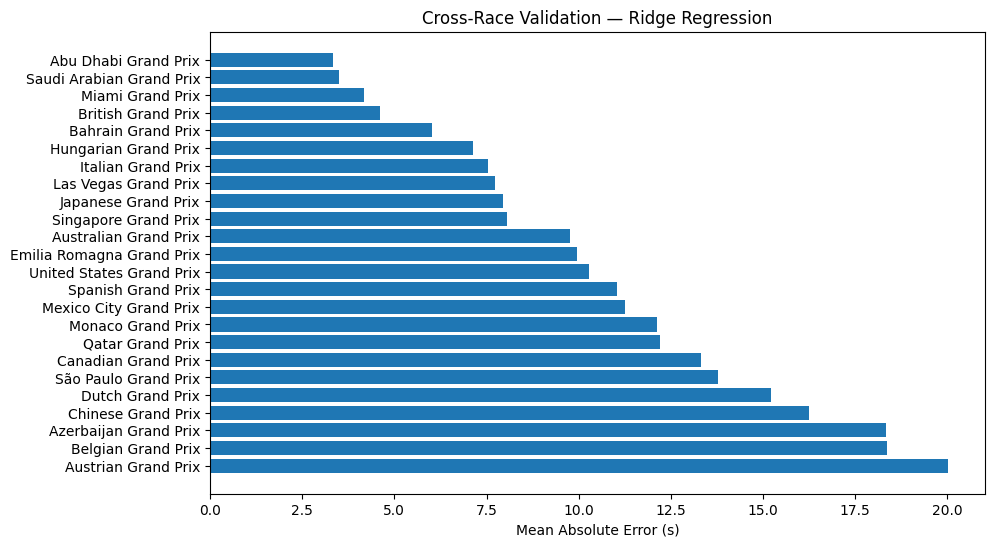

In [ ]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results).sort_values('MAE', ascending=True)
plt.figure(figsize=(10,6))
plt.barh(results_df['event'], results_df['MAE'])
plt.xlabel('Mean Absolute Error (s)')
plt.title('Cross-Race Validation — Ridge Regression')
plt.gca().invert_yaxis()
plt.show()


###8- Ridge Coefficient Analysis
We inspect the most influential features (after one-hot encoding).  
Coefficients with the highest absolute values indicate which compounds, drivers, or tracks most affect predicted lap times.


In [ ]:
ridge_model = ridge.named_steps['model']
encoder = ridge.named_steps['preprocess'].named_transformers_['cat']
feature_names = list(encoder.get_feature_names_out(categorical)) + numeric
coefs = pd.Series(ridge_model.coef_, index=feature_names).sort_values(key=abs, ascending=False)
coefs.head(10)


,0
event_Austrian Grand Prix,-19.253154
event_Belgian Grand Prix,17.543810
event_Azerbaijan Grand Prix,17.475220
compound_WET,16.048815
event_Chinese Grand Prix,15.317711
event_Dutch Grand Prix,-14.560939
event_Monaco Grand Prix,-11.087092
event_Spanish Grand Prix,-10.128264
event_United States Grand Prix,9.729463
event_Emilia Romagna Grand Prix,-9.115365


### Actual vs Predicted Lap Times
A scatter plot compares actual lap times (x-axis) and predicted lap times (y-axis) for the Ridge Regression model.  
Points close to the diagonal indicate accurate predictions; the spread shows model error.


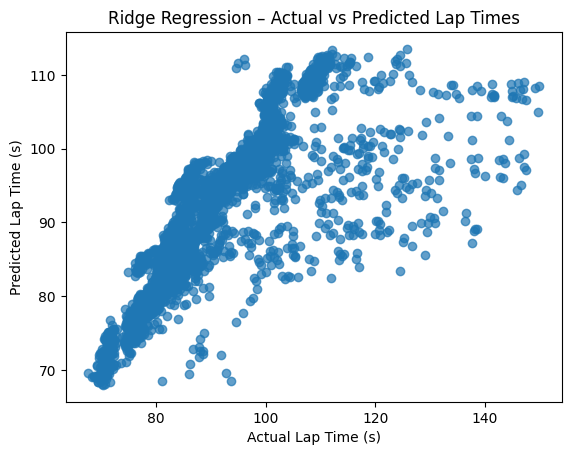

In [ ]:
plt.scatter(y_test, preds_ridge, alpha=0.7)
plt.xlabel("Actual Lap Time (s)")
plt.ylabel("Predicted Lap Time (s)")
plt.title("Ridge Regression – Actual vs Predicted Lap Times")
plt.show()


###  Interpretation — Ridge Regression Baseline Results

- **Ridge Regression slightly outperforms Linear Regression**, achieving a similar MAE (~3.71 s), showing stable and consistent results.  
- **Low MAE races** (e.g., *Abu Dhabi*, *Saudi Arabia*, *Miami*) indicate circuits where tyre wear and lap times are easier to model.  
- **High MAE races** (e.g., *Austria*, *Belgium*, *Azerbaijan*) suggest that unpredictable conditions or track layouts add noise to lap-time prediction.  
- The **scatter plot** shows most predictions aligned along the diagonal, confirming that the model captures overall lap-time trends well.  
- Remaining spread indicates **track-specific and tyre degradation dynamics** that linear models cannot fully capture — motivation for **Report 3’s non-linear or sequential models (RNN/LSTM)**.
